In [151]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

%matplotlib widget


In [152]:
condition = "4mod_basic_s126"
checkpoint_epoch = 2
n_samples_test = 1000
split = "test"

In [ ]:
experiment_name = condition
modules = get_setup_modules('syn', experiment_name)
global_workspace = get_global_workspace("syn", experiment_name, epoch=checkpoint_epoch, modules=modules)
data_module = get_data_module("syn",  experiment_name, modules=modules)

test_samples = get_data_samples(data_module, n_samples_test, split=split)
original_colors = test_samples[frozenset({'color', 'cat', 'position', 'v_latents'})]['color']
original_position = test_samples[frozenset({'color', 'cat', 'position', 'v_latents'})]['position']
original_v_latents = test_samples[frozenset({'color', 'cat', 'position', 'v_latents'})]['v_latents']
original_cat = test_samples[frozenset({'color', 'cat', 'position', 'v_latents'})]['cat']

cat = original_cat

domain_mods = global_workspace.domain_mods
gw_mod = global_workspace.gw_mod
latent_domains = global_workspace.encode_domains(test_samples)

visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods["v_latents"])

original_images_rgb = visual_module.decode_images(original_v_latents)



/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
/home/luc

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/4mod_basic_s126_biased_00/checkpoints/save-epoch=2.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/4mod_basic_s126_biased_00/checkpoints/save-epoch=2.ckpt


In [154]:
latents_source_v_latents = latent_domains[frozenset({'v_latents'})]

# translation_v_latents_to_cat
z_from_v = gw_mod.encode(latents_source_v_latents)['v_latents']
x_pred_1 = gw_mod.decode(z_from_v)
x_pred_1['cat'] = F.one_hot(torch.argmax(x_pred_1['cat'], dim=1), num_classes=3).float()
x_pred_1 = {frozenset({'cat'}): x_pred_1}
x_pred_1 = global_workspace.encode_domains(x_pred_1)

latents_source_2 = x_pred_1[frozenset({'cat'})]
z_cat = gw_mod.encode(latents_source_2)['cat']

# translation_v_latents_to_position and fusion z_cat/z_pos
x_pos = gw_mod.decode(z_from_v)
z_pos = gw_mod.encode(x_pos)['position']
z_pos_cat = 0.5*z_pos + 0.5*z_cat

# translation_v_latents_to_cat_to_color
t = gw_mod.decode(z_cat, domains={'color', 'v_latents'})
color_from_2 = t['color']
v_from_2  = t['v_latents']

# translation_v_latents_to_cat_to_color to v_latents
z_color_from_2 = gw_mod.encode({'color': color_from_2})['color']
t = gw_mod.decode(z_color_from_2, domains={'v_latents', 'color'})
v_from_color_from_2 = t['v_latents']
test = t['color']

# fusion des décodages vers v_latents: v => a => v et v=> a => c => v
z_fusion = 0.5*z_color_from_2 + 0.5*z_pos_cat
t = gw_mod.decode(z_fusion, domains={'v_latents'})
v_from_fusion = t['v_latents']

/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [155]:
latents_source_v_latents = latent_domains[frozenset({'v_latents'})]

# translation_v_latents_to_cat
z_from_v = gw_mod.encode(latents_source_v_latents)['v_latents']
x_pred_1 = gw_mod.decode(z_from_v)
x_pred_1['cat'] = F.one_hot(torch.argmax(x_pred_1['cat'], dim=1), num_classes=3).float()
x_pred_1 = {frozenset({'cat'}): x_pred_1}
x_pred_1 = global_workspace.encode_domains(x_pred_1)

latents_source_2 = x_pred_1[frozenset({'cat'})]
z_cat = gw_mod.encode(latents_source_2)['cat']

# translation_v_latents_to_position and fusion z_cat/z_color
x_col = gw_mod.decode(z_from_v)
z_col = gw_mod.encode(x_col)['color']
z_col_cat = 0.5*z_col + 0.5*z_cat

# translation_v_latents_to_cat_to_position
t = gw_mod.decode(z_cat, domains={'position', 'v_latents'})
position_from_2 = t['position']
v_from_2  = t['v_latents']

# translation_v_latents_to_cat_to_position to v_latents
z_position_from_2 = gw_mod.encode({'position': position_from_2})['position']
t = gw_mod.decode(z_position_from_2, domains={'v_latents'})
v_from_position_from_2 = t['v_latents']

# fusion des décodages vers v_latents: v => a => v et v=> a => c => v
z_fusion = 0.5*z_position_from_2 + 0.5*z_col_cat
t = gw_mod.decode(z_fusion, domains={'v_latents'})
v_from_fusion = t['v_latents']

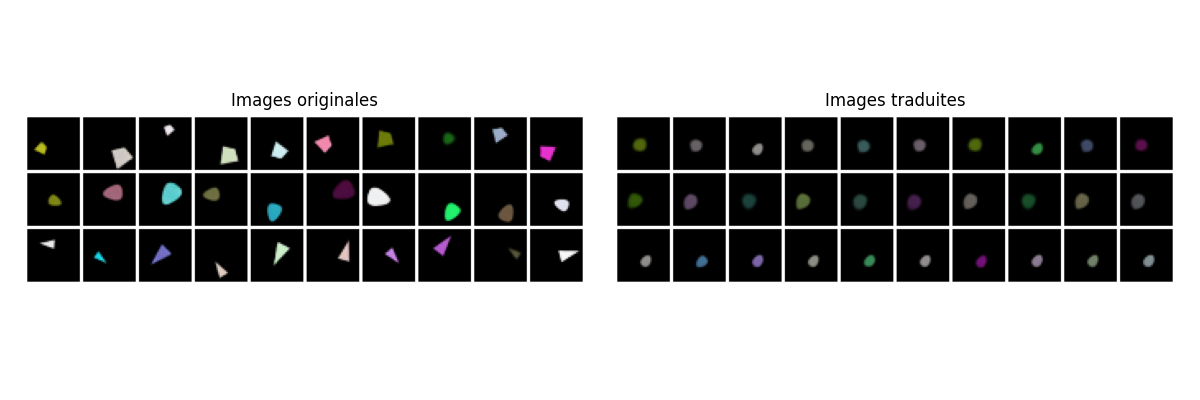

In [156]:
visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods["v_latents"])

decoded_images_dt= visual_module.decode_images(v_from_fusion)
original_images_rgb = visual_module.decode_images(original_v_latents)

fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 10), get_n_per_category(decoded_images_dt, cat, 10))
plt.show()


In [157]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def evaluate_robust_transfer(rep_orig, rep_syn, category, n_iterations=50):
    """
    Exécute l'évaluation n_iterations fois pour obtenir des stats robustes.
    """
    all_results = {"Original": [], "Synesthesia": []}
    
    # Conversion et préparation des labels
    y = torch.argmax(category, dim=1).cpu().numpy() if category.dim() > 1 else category.cpu().numpy()
    
    # On pré-normalise les données (important pour la régression logistique)
    scaler = StandardScaler()
    
    for i in range(n_iterations):
        for name, data in [("Original", rep_orig), ("Synesthesia", rep_syn)]:
            X = data.detach().cpu().numpy()
            X = scaler.fit_transform(X) # Normalisation pour stabiliser la convergence
            
            # Split aléatoire avec stratification (pour garder l'équilibre des classes)
            # random_state n'est PAS fixé ici pour varier à chaque itération
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, train_size=0.01, stratify=y
            )
            
            # Entraînement
            clf = LogisticRegression(max_iter=1000, solver='lbfgs')
            clf.fit(X_train, y_train)
            
            all_results[name].append(clf.score(X_test, y_test))

    # --- Calcul des statistiques ---
    stats = {}
    for name in all_results:
        scores = np.array(all_results[name])
        stats[name] = {
            "mean": np.mean(scores),
            "std": np.std(scores),
            "ci_95": 1.96 * np.std(scores) / np.sqrt(n_iterations)
        }
        
    # --- Visualisation ---
    plt.figure(figsize=(10, 5))
    sns.kdeplot(all_results["Original"], fill=True, label=f"Original (μ={stats['Original']['mean']:.2f})")
    sns.kdeplot(all_results["Synesthesia"], fill=True, label=f"Synesthesia (μ={stats['Synesthesia']['mean']:.2f})")
    plt.title(f"Distribution des scores sur {n_iterations} itérations (Train Size: 1.5%)")
    plt.xlabel("Accuracy")
    plt.legend()
    plt.show()

    return stats

# Utilisation
# stats = evaluate_robust_transfer(rep_orig, rep_syn, category, n_iterations=100)

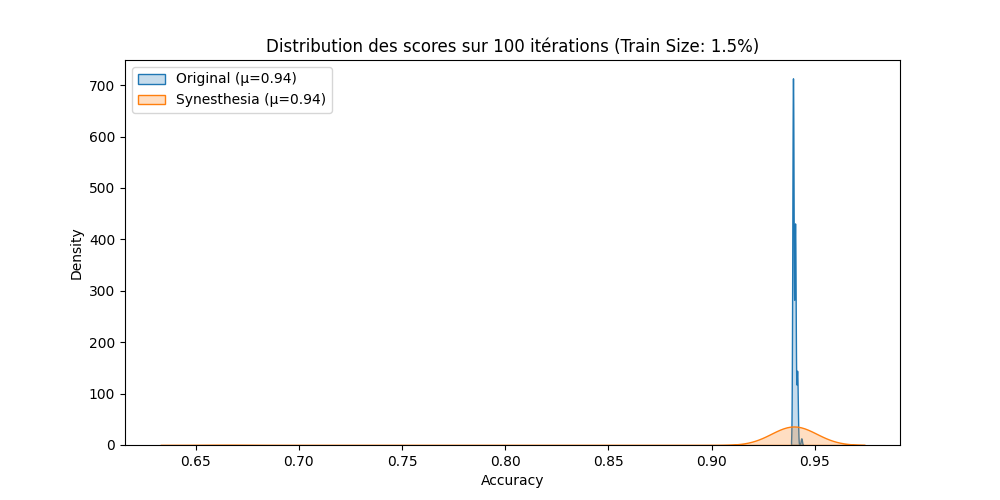

{'Original': {'mean': 0.939989898989899,
  'std': 0.0007705289916986871,
  'ci_95': 0.00015102368237294265},
 'Synesthesia': {'mean': 0.9370909090909091,
  'std': 0.027288091444814182,
  'ci_95': 0.00534846592318358}}

In [158]:
evaluate_robust_transfer(z_position_from_2, z_cat, cat, n_iterations=100)